In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nguynbnhnhinmai/nyc-public-school-test-result-scores", output_dir = 'datasets/nyc-public-school-test-result-scores')

print("Path to dataset files:", path)

100%|██████████| 8.43k/8.43k [00:00<00:00, 4.32MB/s]

Extracting files...
Path to dataset files: datasets/nyc-public-school-test-result-scores


# Importing data

In [4]:
import pandas as pd 
import numpy as np 

df = pd.read_csv('datasets/nyc-public-school-test-result-scores/schools_modified.csv')

print("Shape of the dataset:", df.shape)

Shape of the dataset: (375, 7)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school_name      375 non-null    str    
 1   borough          375 non-null    str    
 2   building_code    375 non-null    str    
 3   average_math     375 non-null    int64  
 4   average_reading  375 non-null    int64  
 5   average_writing  375 non-null    int64  
 6   percent_tested   355 non-null    float64
dtypes: float64(1), int64(3), str(3)
memory usage: 20.6 KB


In [6]:
df.head()

,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,NaN
1,Essex Street Academy,Manhattan,M445,395,411,387,78.9
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.1
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.9
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.7


In [8]:
df.columns

Index(['school_name', 'borough', 'building_code', 'average_math',
       'average_reading', 'average_writing', 'percent_tested'],
      dtype='str')

In [9]:
df['borough'].value_counts()

borough
Brooklyn         109
Bronx             98
Manhattan         89
Queens            69
Staten Island     10
Name: count, dtype: int64

In [ ]:
# check duplicated rows based on 'school_name'
duplicated_rows = df[df.duplicated(subset=['school_name'], keep=False)]
print("Duplicated rows based on 'school_name':")
print(duplicated_rows.shape[0])

Duplicated rows based on 'school_name':
0


In [14]:
# check missing values 

missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
school_name         0
borough             0
building_code       0
average_math        0
average_reading     0
average_writing     0
percent_tested     20
dtype: int64


In [18]:
df[df.isnull().any(axis=1)]

,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,NaN
19,Urban Assembly School of Business for Young Women,Manhattan,M282,418,420,417,NaN
38,High School of Hospitality Management,Manhattan,M535,451,433,424,NaN
57,Frederick Douglass Academy II Secondary School,Manhattan,M088,390,384,373,NaN
76,Jacqueline Kennedy Onassis High School,Manhattan,M486,418,422,415,NaN
95,Tottenville High School,Staten Island,R455,494,476,476,NaN
114,Bronx International High School,Bronx,X400,355,330,320,NaN
133,West Bronx Academy for the Future,Bronx,X435,404,383,378,NaN
152,Bronx High School for the Visual Arts,Bronx,X839,408,428,404,NaN
171,Kingsbridge International High School,Bronx,X430,366,311,310,NaN


In [24]:
# filling missing values with mean corresponding to each borough 

df['percent_tested'] = df['percent_tested'].fillna(df.groupby('borough')['percent_tested'].transform('mean'))

print("Missing values in 'percent_tested' after filling:", df['percent_tested'].isnull().sum())
df.head()

Missing values in 'percent_tested' after filling: 0


,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,71.390476
1,Essex Street Academy,Manhattan,M445,395,411,387,78.900000
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.100000
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.900000
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.700000


# EDA

In [34]:
df.groupby('borough')[['average_math']].agg(['mean', 'median', 'std']) \
  .sort_values(by=('average_math', 'mean'), ascending=False)

average_math                  
                      mean median        std
borough                                     
Staten Island   486.200000  465.5  83.132825
Queens          462.362319  448.0  71.890229
Manhattan       455.887640  433.0  83.818315
Brooklyn        416.403670  395.0  60.481420
Bronx           404.357143  395.5  52.215898

In [35]:
df.groupby('borough')[['average_reading']].agg(['mean', 'median', 'std']) \
  .sort_values(by=('average_reading', 'mean'), ascending=False)

average_reading                  
                         mean median        std
borough                                        
Staten Island      478.500000  463.0  66.850164
Manhattan          444.932584  428.0  73.930987
Queens             443.260870  428.0  61.712724
Brooklyn           410.761468  398.0  48.914684
Bronx              402.520408  400.5  49.224340

In [36]:
df.groupby('borough')[['average_writing']].agg(['mean', 'median', 'std']) \
  .sort_values(by=('average_writing', 'mean'), ascending=False)

average_writing                  
                         mean median        std
borough                                        
Staten Island      474.300000  459.0  72.671330
Queens             439.855072  424.0  66.233383
Manhattan          439.314607  415.0  76.387707
Brooklyn           403.091743  394.0  49.657072
Bronx              395.846939  391.5  51.304298

In [40]:
df.groupby('borough')[['percent_tested']].agg(['mean', 'median', 'std']) \
  .sort_values(by=('percent_tested', 'mean'), ascending=False)

percent_tested                      
                        mean     median        std
borough                                           
Manhattan          71.390476  71.390476  17.419801
Queens             69.313846  71.100000  18.829114
Staten Island      66.111111  65.155556  18.168009
Brooklyn           62.640385  62.000000  16.269709
Bronx              58.653763  58.653763  18.465786

In [37]:
df['SAT_average'] = df[['average_math', 'average_reading', 'average_writing']].mean(axis=1)

df.groupby('borough')[['SAT_average']].agg(['mean', 'median', 'std']) \
  .sort_values(by=('SAT_average', 'mean'), ascending=False)

SAT_average                       
                     mean      median        std
borough                                         
Staten Island  479.666667  460.666667  74.101199
Queens         448.492754  430.000000  65.084300
Manhattan      446.711610  428.000000  76.764713
Brooklyn       410.085627  395.333333  51.622809
Bronx          400.908163  396.666667  50.131300

In [38]:
df.head()

,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested,SAT_average
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,71.390476,619.666667
1,Essex Street Academy,Manhattan,M445,395,411,387,78.900000,397.666667
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.100000,420.333333
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.900000,509.666667
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.700000,399.000000


# Visualization

<Axes: xlabel='borough', ylabel='average_math'>

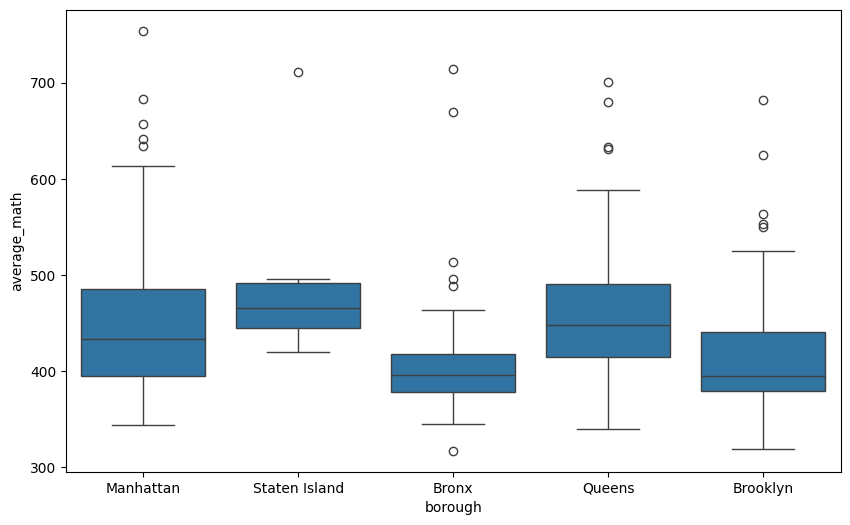

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='borough', y='average_math', data=df)

In [48]:
pv_sat = df.groupby('borough')[['SAT_average']].agg(['mean', 'median', 'std']) \
  .sort_values(by=('SAT_average', 'mean'), ascending=False)
pv_sat

SAT_average                       
                     mean      median        std
borough                                         
Staten Island  479.666667  460.666667  74.101199
Queens         448.492754  430.000000  65.084300
Manhattan      446.711610  428.000000  76.764713
Brooklyn       410.085627  395.333333  51.622809
Bronx          400.908163  396.666667  50.131300

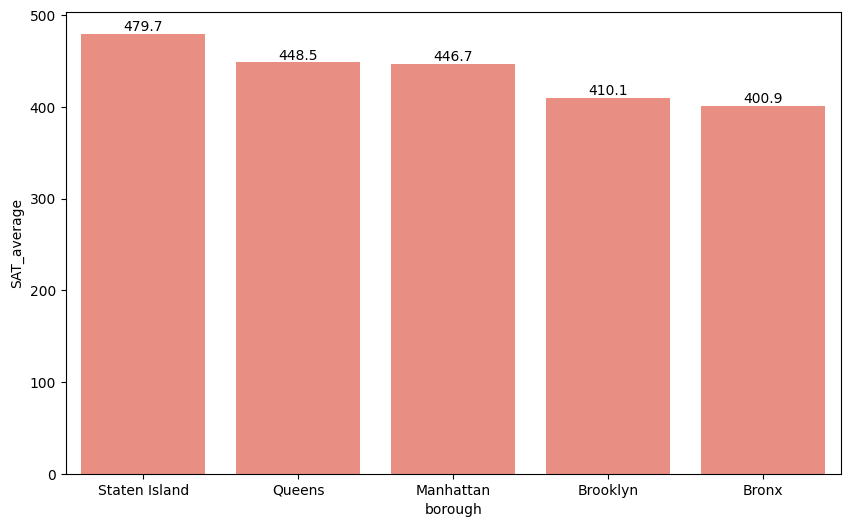

In [65]:
order = df.groupby('borough')['SAT_average'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='borough',
    y='SAT_average',
    data=df,
    estimator=np.mean,
    order=order,
    color='salmon',
    errorbar= None
)

for i, b in enumerate(order):
    v = pv_sat.loc[b, ('SAT_average', 'mean')]
    plt.text(i, v, f"{v:.1f}", ha='center', va='bottom') # text (x , y , text to display, horizontal alignment, vertical alignment)